In [8]:
# Write a util function called merge_celltypes that does the 0.2 filtration and maxes them into one giant adata object with however many spots
# And then see if COMMOT can handle it.

In [9]:
import sys
import os
import importlib

sys.path.insert(0, os.path.abspath('..'))


In [ ]:
import scanpy as sc
import squidpy as sq
import importlib
import model
importlib.reload(model)
from model import CitegeistModel  # Now directly import from the module
# Reload the model module if you're actively developing

import scanpy as sc
from model.utils import plot_neighbors_with_fixed_radius


cell_profiles = {
    "Cancer Cells": {
        "Major": ["EPCAM-1"],
        "Minor": ["SDC1-1",  "KRT5-1"]  # CD138 - possible cancer stem cell marker
    },
    "Macrophages": {
        "Major": ["CD68-1" ],  # General macrophage and M2-polarized macrophages
        "Minor": ["CD14-1"]  # Monocyte/macrophage lineage marker
    },
    "CD4 T Cells": {
        "Major": ["CD3E-1", "CD4-1"],  # General, Helper, and Cytotoxic T cells
    },
    "CD8 T Cells": {
        "Major": ["CD3E-1", "CD8A-1"],  # General, Helper, and Cytotoxic T cells
    },
    "B Cells": {
        "Major": ["MS4A1-1", "CD19-1"],  # General B cell markers and developmental marker
    },
    "Endothelial Cells": {
        "Major": ["PECAM1-1"],  # CD31 - endothelial cell marker
    },
    "Fibroblasts": {
        "Major": ["ACTA2-1"],  # α-SMA - myofibroblast marker, indicates activated stroma
    }
}


# Load dataset
path_to_visium_folder ="/bgfs/alee/LO_LAB/General/Lab_Data/20240510_Neil_SpatialSequencing_AgePatients/SpaceRanger_OUT/MWS23-10650/outs"
adata = sq.read.visium(path_to_visium_folder, counts_file='filtered_feature_bc_matrix.h5', load_images=True, gex_only=False)

# Initialize the model
model = CitegeistModel(sample_name="MWS23-10650", adata=adata, output_folder='output')

# Load cell profile dictionary
model.load_cell_profile_dict(cell_profiles)

# Preprocess and run models
# Split into gene expression and antibody capture datasets
model.split_adata()

model.filter_gex(nonzero_percentage=0.01, mean_expression_threshold=1.1, min_counts=100)

model.copy_gex_to_protein_adata()
# Preprocess datasets
model.preprocess_gex()
model.preprocess_antibody()

# Plot cell proportions (Append cell proportions) 
model.append_proportions_to_adata(key='finetuned')

# Plot cell proportions (Append cell proportions) 
model.append_gex_to_adata(pass_number=1)

prop_gex_adata = model.get_adata()

print(prop_gex_adata)

In [5]:
import commot as ct
import scanpy as sc
import pandas as pd
import numpy as np

In [6]:
import importlib
import model
importlib.reload(model)
from model.analysis_functions import filter_spots_by_celltype_proportion, expand_prop_gex_adata

expanded_adata = expand_prop_gex_adata(prop_gex_adata, celltype_profile_dict=cell_profiles)
print(expanded_adata)

AnnData object with n_obs × n_vars = 7362 × 10029
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts', 'celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read', 'secondary_name', 'sequence'
    uns: 'spatial'
    obsm: 'spatial'
    layers: 'Endothelial_Cells_genes_pass1', 'Fibroblasts_genes_pass1', 'CD8_T_Cells_genes_pass1', 'Macrophages_genes_pass1', 'CD4_T_Cells_genes_pass1', 'Cancer_Cells_genes_pass1', 'B_Cells_genes_pass1'


In [7]:
df_ligrec=ct.pp.ligand_receptor_database(database='CellChat', species='human')

df_cellchat_filtered = ct.pp.filter_lr_database(df_ligrec, expanded_adata, min_cell_pct=0.01)

print(df_cellchat_filtered)

         0                    1         2                   3
0    TGFB3        TGFBR1_TGFBR2      TGFb  Secreted Signaling
1    TGFB3        ACVR1B_TGFBR2      TGFb  Secreted Signaling
2    TGFB3  ACVR1_TGFBR1_TGFBR2      TGFb  Secreted Signaling
3    GDF11        TGFBR1_ACVR2A       GDF  Secreted Signaling
4    GDF11        TGFBR1_ACVR2B       GDF  Secreted Signaling
..     ...                  ...       ...                 ...
95    GAS6                  AXL       GAS  Secreted Signaling
96    GAS6                MERTK       GAS  Secreted Signaling
97     GRN                SORT1       GRN  Secreted Signaling
98  LGALS9               HAVCR2  GALECTIN  Secreted Signaling
99  LGALS9                 CD44  GALECTIN  Secreted Signaling

[100 rows x 4 columns]


... storing 'celltype' as categorical
... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical


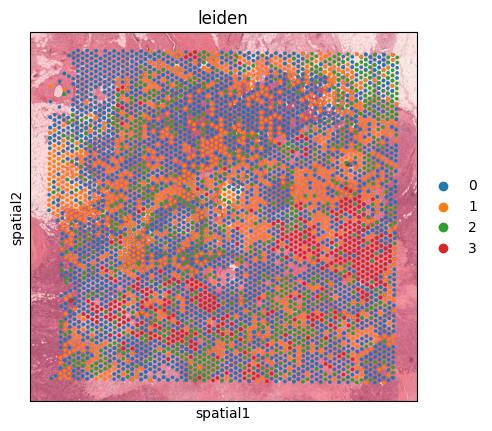

In [8]:
sc.tl.pca(expanded_adata, svd_solver='arpack')
sc.pp.neighbors(expanded_adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(expanded_adata)
sc.tl.leiden(expanded_adata, resolution=0.4)
sc.pl.spatial(expanded_adata, color='leiden')

In [9]:
ct.tl.spatial_communication(expanded_adata, database_name='cellchat', df_ligrec=df_cellchat_filtered, dis_thr=500, heteromeric=True, pathway_sum=False)

In [10]:
expanded_adata.write("./examples/expanded_adata_dis_thr_500_nosum.h5ad")

In [11]:
print(expanded_adata)

AnnData object with n_obs × n_vars = 7362 × 10029
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts', 'celltype', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read', 'secondary_name', 'sequence'
    uns: 'spatial', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'commot-cellchat-info'
    obsm: 'spatial', 'X_pca', 'X_umap', 'commot-cellchat-sum-sender', 'commot-cellchat-sum-receiver'
    varm: 'PCs'
    layers: 'Endothelial_Cells_genes_pass1', 'Fibroblasts_genes_pass1', 'CD8_T_Cells_genes_pass1', 'Macrophages_genes_pass1', 'CD4_T_Cells_genes_pass1', 'Cancer_Cells_genes_pass1', 'B_Cells_genes_pass1'
    obsp: 'distances', 'connectivities', 'commot-cellchat-GDF11-ACVR1B_ACVR2B', 'commot-cellchat-GDF11-TGFBR1_ACVR2A', 'commot-cellchat-GDF11-TGFBR1_ACVR2B', 'commo

In [12]:
sender_signal = expanded_adata.obsm['commot-cellchat-sum-sender']
reciever_signal = expanded_adata.obsm['commot-cellchat-sum-receiver']


In [13]:
print(sender_signal.head())

                                 s-GDF11-ACVR1B_ACVR2B  s-GDF11-TGFBR1_ACVR2A  \
AACACTTGGCAAGGAA-1_Cancer Cells                    0.0                    0.0   
AACAGGAAGAGCATAG-1_Cancer Cells                    0.0                    0.0   
AACAGGATTCATAGTT-1_Cancer Cells                    0.0                    0.0   
AACAGGTTATTGCACC-1_Cancer Cells                    0.0                    0.0   
AACAGTCAGGCTCCGC-1_Cancer Cells                    0.0                    0.0   

                                 s-GDF11-TGFBR1_ACVR2B  s-TNFSF10-TNFRSF10A  \
AACACTTGGCAAGGAA-1_Cancer Cells                    0.0                  0.0   
AACAGGAAGAGCATAG-1_Cancer Cells                    0.0                  0.0   
AACAGGATTCATAGTT-1_Cancer Cells                    0.0                  0.0   
AACAGGTTATTGCACC-1_Cancer Cells                    0.0                  0.0   
AACAGTCAGGCTCCGC-1_Cancer Cells                    0.0                  0.0   

                                 s-CSF

In [14]:
# Calculate the mean of each column
series = sender_signal.mean()
# Filter columns with non-zero means
nonzero_series = series[series != 0]

# Sort columns by mean values in descending order
nonzero_series.sort_values(ascending=False, inplace=True)

nonzero_series.head(20)

s-total-total      5.801767
s-MK               1.131674
s-SPP1             0.485322
s-MIF              0.368378
s-GAS              0.318935
s-SEMA3            0.311396
s-GDF              0.307664
s-ANGPTL           0.290273
s-GDF15-TGFBR2     0.266911
s-MDK-NCL          0.265280
s-MDK-SDC2         0.262076
s-PDGF             0.256350
s-MDK-SDC4         0.253303
s-CXCL             0.252571
s-VEGF             0.234311
s-MIF-CD74_CD44    0.219422
s-CCL              0.218701
s-MDK-LRP1         0.214262
s-SPP1-CD44        0.209603
s-SEMA3C-PLXND1    0.196324
dtype: float64

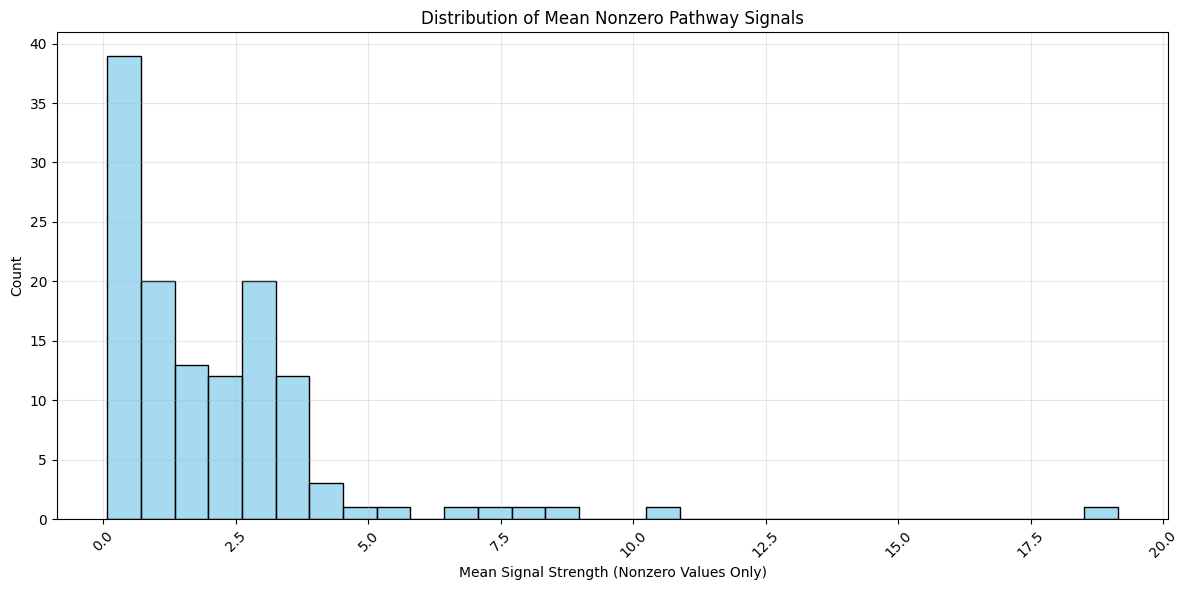


Top 20 pathways by mean nonzero signal strength:
s-total-total      19.136472
s-MK               10.667588
s-FGF               8.576271
s-ANGPTL            7.973845
s-SPP1              7.189017
s-GALECTIN          6.761891
s-FGF7-FGFR1        5.399806
s-IGF               4.857225
s-PDGFA-PDGFRB      4.132095
s-VISFATIN          3.959865
s-CCL14-ACKR1       3.896929
s-LGALS9-CD44       3.873184
s-ANGPTL4-SDC4      3.703007
s-SEMA3C-PLXND1     3.677710
s-PDGF              3.554143
s-CCL               3.515444
s-ADM-CALCRL        3.483568
s-CALCR             3.483568
s-IGF1-IGF1R        3.479351
s-TGFb              3.353448
dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


sender_signal = expanded_adata.obsm['commot-cellchat-sum-sender']
reciever_signal = expanded_adata.obsm['commot-cellchat-sum-receiver']

# Calculate the mean of nonzero values for each column
series = sender_signal.apply(lambda x: x[x != 0].mean())
# Filter columns with non-zero means
nonzero_series = series[series != 0]

# Print top 20 pathways
print("\nTop 20 pathways by mean nonzero signal strength:")
print(nonzero_series.sort_values(ascending=False).head(20))

# Create figure and axis with a larger size
plt.figure(figsize=(12, 6))

# Create histogram using seaborn for better styling
sns.histplot(data=nonzero_series, bins=30, color='skyblue', edgecolor='black')

# Customize the plot
plt.title('Distribution of Mean Nonzero Pathway Signals', fontsize=12)
plt.xlabel('Mean Signal Strength (Nonzero Values Only)', fontsize=10)
plt.ylabel('Count', fontsize=10)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()



In [16]:
# Add celltype as an categorial obs and then run all the ct functions.

expanded_adata.obs['celltype'] = expanded_adata.obs_names.str.split('_').str[1]
expanded_adata.obs['celltype'] = expanded_adata.obs['celltype'].astype('category')


In [17]:
# Add this before the plotting command to check for NaN values
print("NaN values in spatial coordinates:", 
      np.any(np.isnan(expanded_adata.obsm["spatial"])))

# You can also check which spots have NaN coordinates
if np.any(np.isnan(expanded_adata.obsm["spatial"])):
    nan_spots = np.where(np.isnan(expanded_adata.obsm["spatial"]).any(axis=1))[0]
    print("Spots with NaN coordinates:", nan_spots)

NaN values in spatial coordinates: True
Spots with NaN coordinates: [2716 5950]


In [18]:
# Filter out spots with NaN coordinates
valid_spots = ~np.isnan(expanded_adata.obsm["spatial"]).any(axis=1)
expanded_adata = expanded_adata[valid_spots].copy()

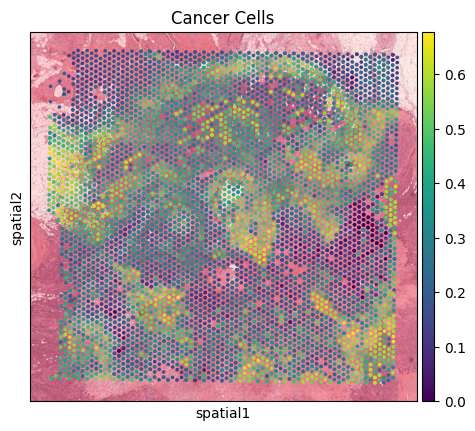

In [19]:
sc.pl.spatial(expanded_adata, color='Cancer Cells')

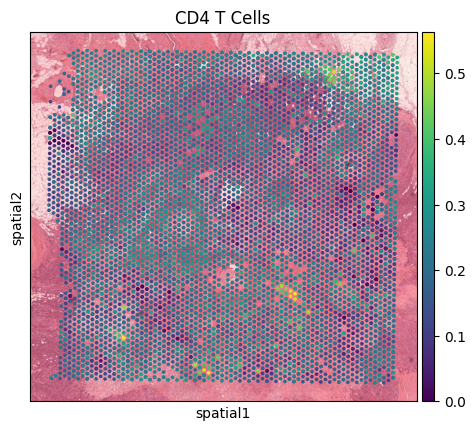

In [26]:
sc.pl.spatial(expanded_adata, color='CD4 T Cells')

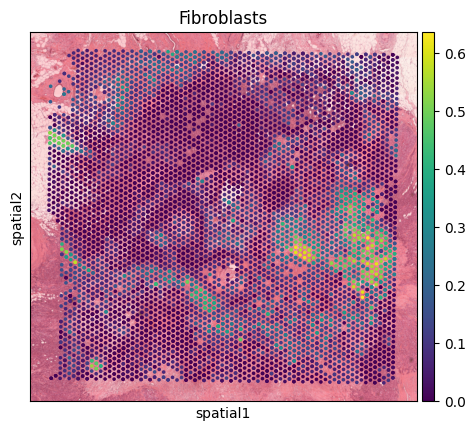

In [20]:
sc.pl.spatial(expanded_adata, color='Fibroblasts')

zero_pct shape: (959,)
AnnData object with n_obs × n_vars = 959 × 10029
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts', 'celltype', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read', 'secondary_name', 'sequence'
    uns: 'spatial', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'commot-cellchat-info'
    obsm: 'spatial', 'X_pca', 'X_umap', 'commot-cellchat-sum-sender', 'commot-cellchat-sum-receiver'
    varm: 'PCs'
    layers: 'Endothelial_Cells_genes_pass1', 'Fibroblasts_genes_pass1', 'CD8_T_Cells_genes_pass1', 'Macrophages_genes_pass1', 'CD4_T_Cells_genes_pass1', 'Cancer_Cells_genes_pass1', 'B_Cells_genes_pass1'
    obsp: 'distances', 'connectivities', 'commot-cellchat-GDF11-ACVR1B_ACVR2B', 'commot-cellchat-GDF11-TGFBR1_ACVR2A', 'commot-cellchat-GDF11-

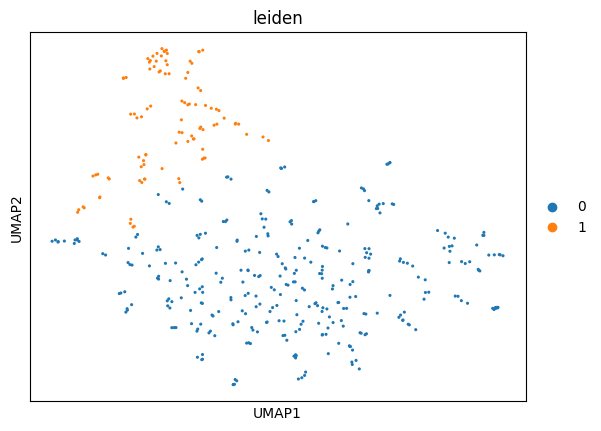

In [25]:
# Filter down the fibroblast layer

fibroblast_adata = expanded_adata[expanded_adata.obs['Fibroblasts'] > 0.2]
# Then set the X matrix to the Macrophage layers
fibroblast_adata.X = fibroblast_adata.layers['Fibroblasts_genes_pass1']
# PCA it
sc.tl.pca(fibroblast_adata, svd_solver='arpack')
# Delete 95% 0 signal spots
# Calculate zero percentage - make sure to use the sparse matrix properly
threshold = 0.95
zero_pct = np.sum(fibroblast_adata.X <= threshold, axis=1) / fibroblast_adata.X.shape[1]
print("zero_pct shape:", zero_pct.shape)
# Now filter

print(fibroblast_adata)
fibroblast_adata = fibroblast_adata[zero_pct < 0.95].copy()
print(fibroblast_adata)
# Cluster it by UMAP
sc.pp.log1p(fibroblast_adata)
sc.pp.pca(fibroblast_adata)
sc.pp.neighbors(fibroblast_adata, n_neighbors=15, use_rep='X_pca')
sc.tl.leiden(fibroblast_adata, resolution=0.2)
sc.tl.umap(fibroblast_adata, min_dist=0.1, spread=1.0)   
sc.pl.umap(fibroblast_adata, color=['leiden'], wspace = 0.6, size = 20)
# See what signals are in each cluster
# Validate them


zero_pct shape: (6360,)
AnnData object with n_obs × n_vars = 6360 × 10029
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts', 'celltype', 'leiden', 'CD4_T_Cells_leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read', 'secondary_name', 'sequence'
    uns: 'spatial', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'commot-cellchat-info', 'CD4_T_Cells_leiden_colors'
    obsm: 'spatial', 'X_pca', 'X_umap', 'commot-cellchat-sum-sender', 'commot-cellchat-sum-receiver', 'commot_sender_vf-cellchat-CCL', 'commot_receiver_vf-cellchat-CCL'
    varm: 'PCs'
    layers: 'Endothelial_Cells_genes_pass1', 'Fibroblasts_genes_pass1', 'CD8_T_Cells_genes_pass1', 'Macrophages_genes_pass1', 'CD4_T_Cells_genes_pass1', 'Cancer_Cells_genes_pass1', 'B_Cells_genes_pass1'
    obsp: 'distances'

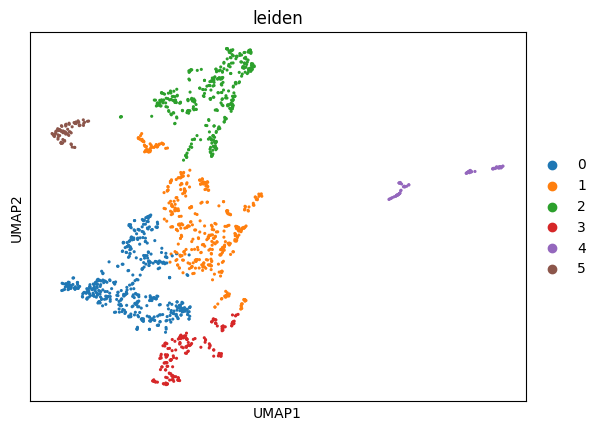

In [36]:

cancer_adata = expanded_adata[expanded_adata.obs['Cancer Cells'] > 0.2]
# Then set the X matrix to the Macrophage layers
cancer_adata.X = cancer_adata.layers['Cancer_Cells_genes_pass1']
# PCA it
sc.tl.pca(cancer_adata, svd_solver='arpack')
# Delete 95% 0 signal spots
# Calculate zero percentage - make sure to use the sparse matrix properly
threshold = 0.95
zero_pct = np.sum(cancer_adata.X <= threshold, axis=1) / cancer_adata.X.shape[1]
print("zero_pct shape:", zero_pct.shape)
# Now filter

print(cancer_adata)
cancer_adata = cancer_adata[zero_pct < 0.95].copy()
print(cancer_adata)
# Cluster it by UMAP
sc.pp.log1p(cancer_adata)
sc.pp.pca(cancer_adata)
sc.pp.neighbors(cancer_adata, n_neighbors=15, use_rep='X_pca')
sc.tl.leiden(cancer_adata, resolution=0.2)
sc.tl.umap(cancer_adata, min_dist=0.1, spread=1.0)   
sc.pl.umap(cancer_adata, color=['leiden'], wspace = 0.6, size = 20)
# See what signals are in each cluster
# Validate them

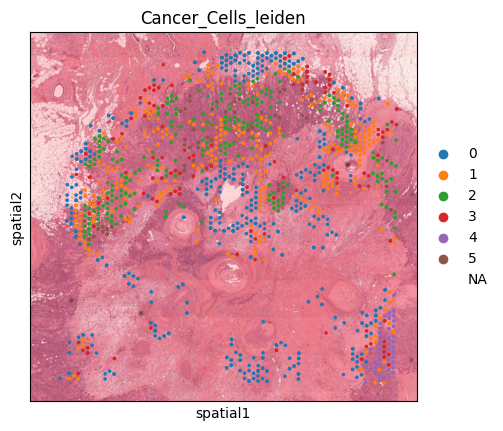

In [37]:
# Append the CD4 T Cell Leiden's back to the expanded_adata
expanded_adata.obs['Cancer_Cells_leiden'] = cancer_adata.obs['leiden']
sc.pl.spatial(expanded_adata, color=['Cancer_Cells_leiden'])

In [39]:
sender_signal = cancer_adata.obsm['commot-cellchat-sum-sender']
reciever_signal = cancer_adata.obsm['commot-cellchat-sum-receiver']

# Calculate the mean of nonzero values for each column
series = sender_signal.apply(lambda x: x[x != 0].mean())
# Filter columns with non-zero means
nonzero_series = series[series != 0]

# Print top 20 pathways
print("\nTop 20 sender pathways in Cancer Cells by mean nonzero signal strength:")
print(nonzero_series.sort_values(ascending=False).head(20))

# Calculate the mean of nonzero values for each column
series = reciever_signal.apply(lambda x: x[x != 0].mean())
# Filter columns with non-zero means
nonzero_series = series[series != 0]

# Print top 20 pathways
print("\nTop 20 receiver pathways in Cancer Cells by mean nonzero signal strength:")
print(nonzero_series.sort_values(ascending=False).head(20))


Top 20 sender pathways in Cancer Cells by mean nonzero signal strength:
s-total-total     16.415008
s-MK               6.999302
s-ANGPTL           6.046756
s-FGF              5.905384
s-SPP1             5.395502
s-GALECTIN         3.536186
s-FGF7-FGFR1       3.375716
s-VISFATIN         3.098074
s-WNT              3.048434
s-IGF              2.928170
s-ANGPTL4-SDC4     2.722853
s-GDF              2.643737
s-FGF7-FGFR2       2.584661
s-ADM-CALCRL       2.512815
s-CALCR            2.512815
s-GDF15-TGFBR2     2.477577
s-SPP1-CD44        2.457796
s-ANGPTL4-SDC2     2.436108
s-TGFb             2.423783
s-NAMPT-INSR       2.387413
dtype: float64

Top 20 receiver pathways in Cancer Cells by mean nonzero signal strength:
r-total-total       17.079937
r-CCL                6.065966
r-MK                 4.365340
r-MIF                3.710249
r-VEGF               3.545296
r-MIF-CD74_CD44      3.309828
r-MIF-CD74_CXCR4     3.277333
r-CXCL               3.078117
r-CXCL12-CXCR4       3.072719
r-C3-IT

<Axes: >

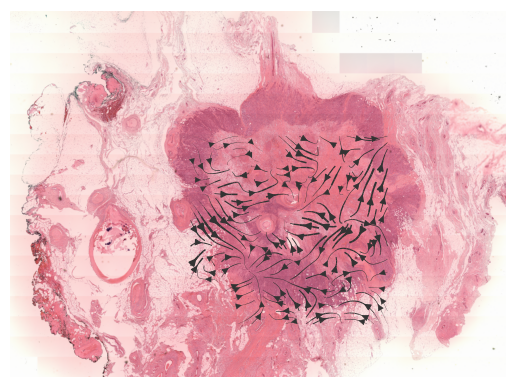

In [41]:
ct.tl.communication_direction(expanded_adata, database_name='cellchat', pathway_name='MK', k=5)
ct.pl.plot_cell_communication(expanded_adata, database_name='cellchat', pathway_name='MK', plot_method='stream', background_legend=True,
    scale=0.00003, ndsize=8, grid_density=0.4, summary='sender', background='image', clustering='Cancer_Cells_leiden', cmap='Alphabet',
    normalize_v = True, normalize_v_quantile=0.995)


zero_pct shape: (4847,)
AnnData object with n_obs × n_vars = 4847 × 10029
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts', 'celltype', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read', 'secondary_name', 'sequence'
    uns: 'spatial', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'commot-cellchat-info'
    obsm: 'spatial', 'X_pca', 'X_umap', 'commot-cellchat-sum-sender', 'commot-cellchat-sum-receiver'
    varm: 'PCs'
    layers: 'Endothelial_Cells_genes_pass1', 'Fibroblasts_genes_pass1', 'CD8_T_Cells_genes_pass1', 'Macrophages_genes_pass1', 'CD4_T_Cells_genes_pass1', 'Cancer_Cells_genes_pass1', 'B_Cells_genes_pass1'
    obsp: 'distances', 'connectivities', 'commot-cellchat-GDF11-ACVR1B_ACVR2B', 'commot-cellchat-GDF11-TGFBR1_ACVR2A', 'commot-cellchat-GDF1

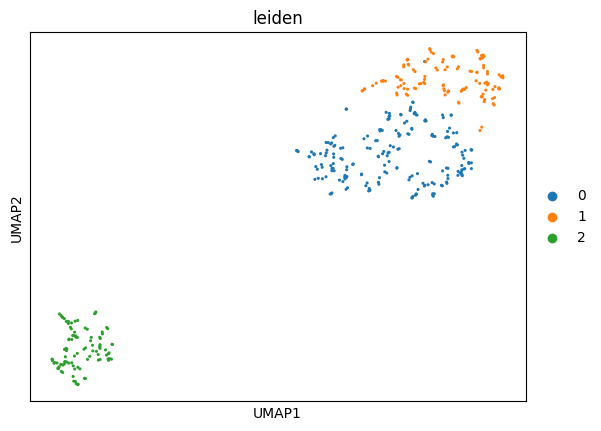

In [28]:
# Filter down the fibroblast layer

cd4_adata = expanded_adata[expanded_adata.obs['CD4 T Cells'] > 0.2]
# Then set the X matrix to the Macrophage layers
cd4_adata.X = cd4_adata.layers['CD4_T_Cells_genes_pass1']
# PCA it
sc.tl.pca(cd4_adata, svd_solver='arpack')
# Delete 95% 0 signal spots
# Calculate zero percentage - make sure to use the sparse matrix properly
threshold = 0.95
zero_pct = np.sum(cd4_adata.X <= threshold, axis=1) / cd4_adata.X.shape[1]
print("zero_pct shape:", zero_pct.shape)
# Now filter

print(cd4_adata)
cd4_adata = cd4_adata[zero_pct < 0.95].copy()
print(cd4_adata)
# Cluster it by UMAP
sc.pp.log1p(cd4_adata)
sc.pp.pca(cd4_adata)
sc.pp.neighbors(cd4_adata, n_neighbors=15, use_rep='X_pca')
sc.tl.leiden(cd4_adata, resolution=0.2)
sc.tl.umap(cd4_adata, min_dist=0.1, spread=1.0)   
sc.pl.umap(cd4_adata, color=['leiden'], wspace = 0.6, size = 20)
# See what signals are in each cluster
# Validate them


In [29]:
# Append the CD4 T Cell Leiden's back to the expanded_adata
expanded_adata.obs['CD4_T_Cells_leiden'] = cd4_adata.obs['leiden']
sc.pl.spatial(expanded_adata, color=['CD4_T_Cells_leiden'])

In [33]:
sender_signal = cd4_adata.obsm['commot-cellchat-sum-sender']
reciever_signal = cd4_adata.obsm['commot-cellchat-sum-receiver']

# Calculate the mean of nonzero values for each column
series = sender_signal.apply(lambda x: x[x != 0].mean())
# Filter columns with non-zero means
nonzero_series = series[series != 0]

# Print top 20 pathways
print("\nTop 20 sender pathways in CD4 T Cells by mean nonzero signal strength:")
print(nonzero_series.sort_values(ascending=False).head(20))

# Calculate the mean of nonzero values for each column
series = reciever_signal.apply(lambda x: x[x != 0].mean())
# Filter columns with non-zero means
nonzero_series = series[series != 0]

# Print top 20 pathways
print("\nTop 20 receiver pathways in CD4 T Cells by mean nonzero signal strength:")
print(nonzero_series.sort_values(ascending=False).head(20))


Top 20 sender pathways in CD4 T Cells by mean nonzero signal strength:
s-total-total          10.885406
s-MK                    5.745930
s-SPP1                  4.699277
s-ANGPTL                4.103614
s-FGF                   3.782224
s-GALECTIN              3.071851
s-FGF7-FGFR1            2.476692
s-CXCL2-ACKR1           2.252056
s-CXCL12-CXCR4          2.240812
s-CXCL                  2.236752
s-WNT                   2.230054
s-CCL8-ACKR1            2.186519
s-GDF                   2.076903
s-SPP1-CD44             2.054258
s-SEMA3C-PLXND1         1.983621
s-MIF                   1.963196
s-TNFSF12-TNFRSF12A     1.888259
s-TWEAK                 1.888259
s-GDF15-TGFBR2          1.842539
s-VISFATIN              1.794198
dtype: float64

Top 20 receiver pathways in CD4 T Cells by mean nonzero signal strength:
r-total-total            12.105062
r-CCL                     5.429132
r-VEGF                    3.977724
r-MIF-CD74_CXCR4          3.912290
r-CXCL12-CXCR4            3.422539
r-CX

<Axes: >

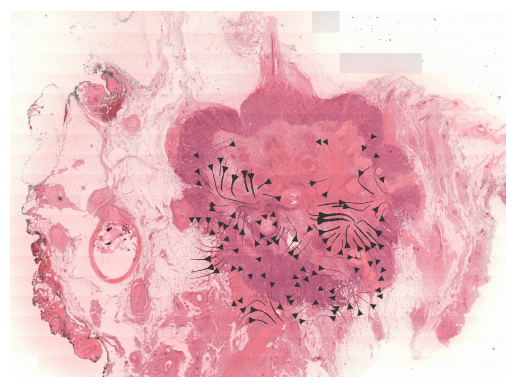

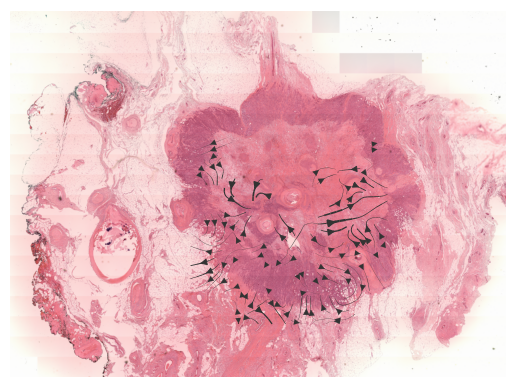

In [34]:
ct.tl.communication_direction(expanded_adata, database_name='cellchat', pathway_name='CCL', k=5)
ct.pl.plot_cell_communication(expanded_adata, database_name='cellchat', pathway_name='CCL', plot_method='stream', background_legend=True,
    scale=0.00003, ndsize=8, grid_density=0.4, summary='sender', background='image', clustering='CD4_T_Cells_leiden', cmap='Alphabet',
    normalize_v = True, normalize_v_quantile=0.995)
ct.pl.plot_cell_communication(expanded_adata, database_name='cellchat', pathway_name='CCL', plot_method='stream', background_legend=True,
    scale=0.00003, ndsize=8, grid_density=0.4, summary='receiver', background='image', clustering='CD4_T_Cells_leiden', cmap='Alphabet',
    normalize_v = True, normalize_v_quantile=0.995)

In [46]:
ct.tl.cluster_communication(expanded_adata, database_name='cellchat', pathway_name='MK', clustering='celltype',
    n_permutations=100)



In [36]:
print(expanded_adata)

AnnData object with n_obs × n_vars = 7360 × 10029
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts', 'celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read', 'secondary_name', 'sequence'
    uns: 'spatial', 'commot-cellchat-info', 'commot_cluster-celltype-cellchat-MK'
    obsm: 'spatial', 'commot-cellchat-sum-sender', 'commot-cellchat-sum-receiver', 'commot_sender_vf-cellchat-MK', 'commot_receiver_vf-cellchat-MK', 'commot_sender_vf-cellchat-FGF', 'commot_receiver_vf-cellchat-FGF'
    layers: 'CD8_T_Cells_genes_pass1', 'Fibroblasts_genes_pass1', 'Endothelial_Cells_genes_pass1', 'B_Cells_genes_pass1', 'CD4_T_Cells_genes_pass1', 'Macrophages_genes_pass1', 'Cancer_Cells_genes_pass1'
    obsp: 'commot-cellchat-CCL2-ACKR1', 'commot-cellchat-PDGFA-PDGFRA', 'commot-cellchat-PD

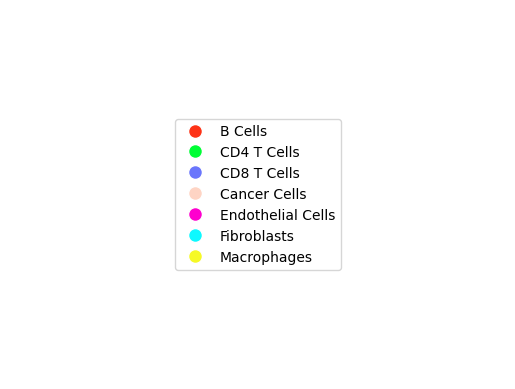

In [50]:
ct.pl.plot_cluster_communication_network(expanded_adata, uns_names=['commot_cluster-celltype-cellchat-MK'],
    nx_node_pos=None, quantile_cutoff = 1, nx_bg_pos=False, p_value_cutoff = 0.10, filename='MK_cluster.pdf', nx_node_cmap='Light24')

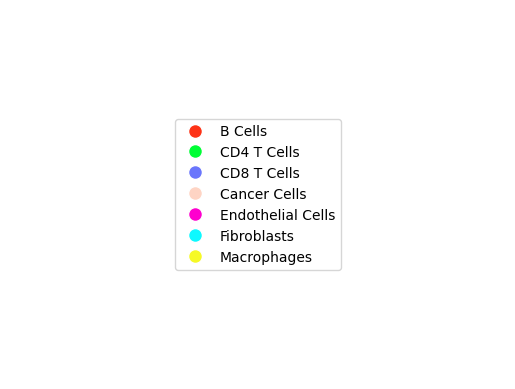

In [48]:
ct.tl.cluster_position(expanded_adata, clustering='celltype')
ct.pl.plot_cluster_communication_network(expanded_adata, uns_names=['commot_cluster-celltype-cellchat-MK'], clustering='celltype',
    nx_node_pos='cluster', nx_pos_idx=np.array([0, 1]), nx_bg_pos=True, nx_bg_ndsize=0.25, p_value_cutoff=5e-2,
    filename='MK_cluster_spatial.pdf', nx_node_cmap='Light24')

In [43]:
top_20_pathways = nonzero_series.sort_values(ascending=False).head(20)

print(top_20_pathways)


r-total-total       17.079937
r-CCL                6.065966
r-MK                 4.365340
r-MIF                3.710249
r-VEGF               3.545296
r-MIF-CD74_CD44      3.309828
r-MIF-CD74_CXCR4     3.277333
r-CXCL               3.078117
r-CXCL12-CXCR4       3.072719
r-C3-ITGAX_ITGB2     2.862069
r-SPP1               2.790740
r-COMPLEMENT         2.779472
r-SPP1-CD44          2.590573
r-GDF15-TGFBR2       2.575222
r-C3-C3AR1           2.561928
r-GAS6-AXL           2.528302
r-GDF                2.524139
r-PDGFC-PDGFRA       2.446704
r-MDK-LRP1           2.257959
r-GAS                2.253776
dtype: float64


In [24]:
print(expanded_adata)

AnnData object with n_obs × n_vars = 7362 × 10029
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'size_factors', 'original_total', 'scaled_total', 'Cancer Cells', 'Macrophages', 'CD4 T Cells', 'CD8 T Cells', 'B Cells', 'Endothelial Cells', 'Fibroblasts', 'celltype', 's-GRN', 'r-GRN'
    var: 'gene_ids', 'feature_types', 'genome', 'isotype_control', 'normalized', 'pattern', 'read', 'secondary_name', 'sequence'
    uns: 'spatial', 'commot-cellchat-info'
    obsm: 'spatial', 'commot-cellchat-sum-sender', 'commot-cellchat-sum-receiver'
    layers: 'B_Cells_genes_pass1', 'Fibroblasts_genes_pass1', 'Endothelial_Cells_genes_pass1', 'CD8_T_Cells_genes_pass1', 'Cancer_Cells_genes_pass1', 'CD4_T_Cells_genes_pass1', 'Macrophages_genes_pass1'
    obsp: 'commot-cellchat-CXCL12-CXCR4', 'commot-cellchat-GAS6-AXL', 'commot-cellchat-GAS6-MERTK', 'commot-cellchat-SEMA3B-NRP1_PLXNA2', 'commot-cellchat-SEMA3B-NRP2_PLXNA3', 'commot-cellchat-SEMA3B-NRP1_PLXNA3', 'commot-cellchat-SEMA3B-NRP2_PLX

In [26]:
print(expanded_adata.obsm['commot-cellchat-sum-sender'])

                                 s-CXCL12-CXCR4  s-GAS6-AXL  s-GAS6-MERTK  \
AACACTTGGCAAGGAA-1_Cancer Cells        0.000000    0.000000      0.000000   
AACAGGAAGAGCATAG-1_Cancer Cells        0.000000    0.000000      0.000000   
AACAGGATTCATAGTT-1_Cancer Cells        0.000000    0.000000      0.000000   
AACAGGTTATTGCACC-1_Cancer Cells        0.000000    0.000000      0.000000   
AACAGTCAGGCTCCGC-1_Cancer Cells        0.000000    0.000000      0.000000   
...                                         ...         ...           ...   
TGTATGGTGCCAAGGT-1_Fibroblasts         0.000000    0.000000      0.000000   
TGTCAACTCATCAACG-1_Fibroblasts         0.000000    0.000000      0.000000   
TGTCCTTCGCCTCGTA-1_Fibroblasts         0.000136    2.912967      1.514846   
TGTTCACTGTCTTCCT-1_Fibroblasts         0.000000    0.000000      0.000000   
TGTTCGCAACCGCCAA-1_Fibroblasts         0.000000    0.000000      0.000000   

                                 s-SEMA3B-NRP1_PLXNA2  s-SEMA3B-NRP2_PLXNA3

In [44]:
# Across all spots, which celltypes are expressing the top 20 pathways the most?

for path in top_20_pathways.index:
    path = path[2:]

    if path == 'total':
        continue

    # Get sender and receiver signals
    sender_signal_df = expanded_adata.obsm['commot-cellchat-sum-sender']
    receiver_signal_df = expanded_adata.obsm['commot-cellchat-sum-receiver']
    
    sender_signal = sender_signal_df[f's-{path}'].copy()
    receiver_signal = receiver_signal_df[f'r-{path}'].copy()

    # Get celltypes
    sender_celltype = sender_signal.index.str.split('_').str[1]
    receiver_celltype = receiver_signal.index.str.split('_').str[1]

    # Group by celltype and get means
    sender_by_celltype = sender_signal.groupby(sender_celltype).mean()
    receiver_by_celltype = receiver_signal.groupby(receiver_celltype).mean()

    # Sort both by mean values
    sender_by_celltype = sender_by_celltype.sort_values(ascending=False)
    receiver_by_celltype = receiver_by_celltype.sort_values(ascending=False)

    print(f"\n=== {path} Pathway ===")
    print("\nTop Sending and Receiving Celltypes:")
    print("-" * 60)
    print(f"{'Sender':25} {'Signal':10} | {'Receiver':25} {'Signal':10}")
    print("-" * 60)

    # Get max length to iterate over
    max_len = max(len(sender_by_celltype), len(receiver_by_celltype))
    
    # Print side by side
    for i in range(max_len):
        sender_cell = ""
        sender_val = ""
        receiver_cell = ""
        receiver_val = ""
        
        if i < len(sender_by_celltype):
            sender_cell = sender_by_celltype.index[i]
            sender_val = f"{sender_by_celltype.iloc[i]:.4f}"
            
        if i < len(receiver_by_celltype):
            receiver_cell = receiver_by_celltype.index[i]
            receiver_val = f"{receiver_by_celltype.iloc[i]:.4f}"
            
        print(f"{sender_cell:25} {sender_val:10} | {receiver_cell:25} {receiver_val:10}")

    print("-" * 60)
    print("\n")
    
    
    



=== total-total Pathway ===

Top Sending and Receiving Celltypes:
------------------------------------------------------------
Sender                    Signal     | Receiver                  Signal    
------------------------------------------------------------
Fibroblasts               21.6456    | Macrophages               21.8015   
Macrophages               20.5378    | Fibroblasts               20.5916   
CD8 T Cells               7.3279     | CD8 T Cells               7.1776    
Cancer Cells              5.7395     | Cancer Cells              5.7604    
Endothelial Cells         3.4751     | Endothelial Cells         3.9209    
CD4 T Cells               1.3512     | B Cells                   3.5009    
B Cells                   0.0657     | CD4 T Cells               1.3885    
------------------------------------------------------------



=== CCL Pathway ===

Top Sending and Receiving Celltypes:
------------------------------------------------------------
Sender              

In [7]:
import omnipath as op

print(op.requests.Intercell.categories())

0.00B [00:00, ?B/s]

('5ht_gprotein', '5ht_ionotropic', '7d_cadherin', '7tm_a', '7tm_a_ogr1_gpr4_7tm_a', '7tm_a_orphan_7tm_a', '7tm_b', '7tm_c', '7tm_d', '7tm_d_olfactory_7tm_d', '7tm_type_b_polypeptide_7tm_b', 'abc', 'abca', 'abcb', 'abcc', 'abcg', 'acid_sensing', 'act_tgfb', 'actin_regulation_adhesome', 'activating_cofactor', 'activating_leukocyte_ig_like', 'active', 'adamts', 'adamts_like', 'adenosine', 'adenosine_7tm_a', 'adherens_junction', 'adhesion', 'adhesion_cytoskeleton_adaptor', 'adhesion_gprotein_coupled_receptor', 'adipo_paqr', 'adiponectin', 'adrenalin', 'adrenergic_7tm_a', 'alk_serine_threonine_kinase_tgf_beta_serine_threonine_kinase', 'angiogenesis_inhibitor_receptor_7tm_b', 'angiopoietin', 'angiotensin', 'anosmin', 'antigen_binding', 'apc', 'apelin_angiotensin_bradykinin_7tm_a', 'apical_cell_membrane', 'apicolateral_cell_membrane', 'aquaporin', 'aquaporins', 'arc', 'artipical_chemokine_receptor', 'atipical_chemokine_receptor', 'atp1b', 'atp_gated', 'atypical_chemokine', 'auxiliary_transpor

In [ ]:
print(op.requests.Annotations.get('CXCL12'))

0.00B [00:00, ?B/s]

     uniprot genesymbol entity_type          source       label  \
0     P48061     CXCL12     protein      CellChatDB        role   
1     P48061     CXCL12     protein      CellChatDB     pathway   
2     P48061     CXCL12     protein      CellChatDB    category   
3     P48061     CXCL12     protein  UniProt_tissue      tissue   
4     P48061     CXCL12     protein  UniProt_tissue       level   
...      ...        ...         ...             ...         ...   
2429  P48061     CXCL12     protein          MSigDB     geneset   
2430  P48061     CXCL12     protein          MSigDB  collection   
2431  P48061     CXCL12     protein          MSigDB     geneset   
2432  P48061     CXCL12     protein          MSigDB  collection   
2433  P48061     CXCL12     protein          MSigDB     geneset   

                                               value  record_id  
0                                             ligand        358  
1                                               CXCL        358

In [4]:
# Query protein info
protein_query = op.interactions.QueryProtein()
results = protein_query.filter_protein('CXCL12')

AttributeError: module 'omnipath.interactions' has no attribute 'QueryProtein'

In [57]:
# Across all spots, which celltypes are expressing the top 20 pathways the most?

for path in top_20_pathways.index:
    path = path[2:]

    if path == 'total':
        continue


    sum_signal_df = expanded_adata.obsm['commot-cellchat-sum-receiver']

    pathway_signal = sum_signal_df[f'r-{path}'].copy()

    celltype = pathway_signal.index.str.split('_').str[1]

    # Group by celltype and get the mean of the pathway signal
    pathway_signal_by_celltype = pathway_signal.groupby(celltype)


    print(pathway_signal_by_celltype)

    # Get mean values for each celltype
    mean_by_celltype = pathway_signal_by_celltype.mean()
    print("\nMean signal by celltype:")
    print(mean_by_celltype)
    
    # Convert to list of values for each celltype for ANOVA
    celltype_values = [group.values for name, group in pathway_signal_by_celltype]
    
    # Perform one-way ANOVA
    from scipy import stats
    f_stat, p_val = stats.f_oneway(*celltype_values)
    
    print(f"\nOne-way ANOVA results:")
    print(f"F-statistic: {f_stat:.4f}")
    print(f"p-value: {p_val:.4e}")
    
    if p_val < 0.05:
        print("There are significant differences between celltypes (p < 0.05)")
    else:
        print("No significant differences between celltypes (p >= 0.05)")

    # Perform Tukey's HSD test
    from statsmodels.stats.multicomp import MultiComparison
    mc = MultiComparison(pathway_signal, celltype)
    tukey_result = mc.tukeyhsd()
    
    print("\nTukey's HSD test results:")
    print(tukey_result)
    
    # Get groups with significantly higher means
    group_means = pathway_signal_by_celltype.mean().sort_values(ascending=False)
    print("\nCelltypes ranked by mean signal:")
    for celltype, mean in group_means.items():
        print(f"{celltype}: {mean:.4f}")
    # Find significant differences
    print("\nSignificantly higher celltypes:")
    pvalues = tukey_result.pvalues.flatten()  # Flatten the pvalue array
    groups = tukey_result.groupsunique
    n_groups = len(groups)
    
    for i in range(n_groups):
        for j in range(n_groups):
            idx = i * n_groups + j
            if idx < len(pvalues):  # Check array bounds
                pval = pvalues[idx]
                if pval < 0.05 and group_means.iloc[i] > group_means.iloc[j]:
                    print(f"{group_means.index[i]} > {group_means.index[j]} (p={pval:.4f})")

    
    
    
    
    
    



Mean signal by celltype:
B Cells               3.500855
CD4 T Cells           1.388458
CD8 T Cells           7.177627
Cancer Cells          5.760390
Endothelial Cells     3.920926
Fibroblasts          20.591594
Macrophages          21.801485
Name: r-total-total, dtype: float64

One-way ANOVA results:
F-statistic: 268.9893
p-value: 3.1833e-312
There are significant differences between celltypes (p < 0.05)

Tukey's HSD test results:
            Multiple Comparison of Means - Tukey HSD, FWER=0.05            
      group1            group2      meandiff p-adj   lower    upper  reject
---------------------------------------------------------------------------
          B Cells       CD4 T Cells  -2.1124 0.9998 -19.5888  15.364  False
          B Cells       CD8 T Cells   3.6768 0.9967 -14.3075  21.661  False
          B Cells      Cancer Cells   2.2595 0.9998 -15.2122 19.7313  False
          B Cells Endothelial Cells   0.4201    1.0 -17.7415 18.5817  False
          B Cells       Fibrobla

... storing 'celltype' as categorical
... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'isotype_control' as categorical
... storing 'normalized' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'secondary_name' as categorical
... storing 'sequence' as categorical


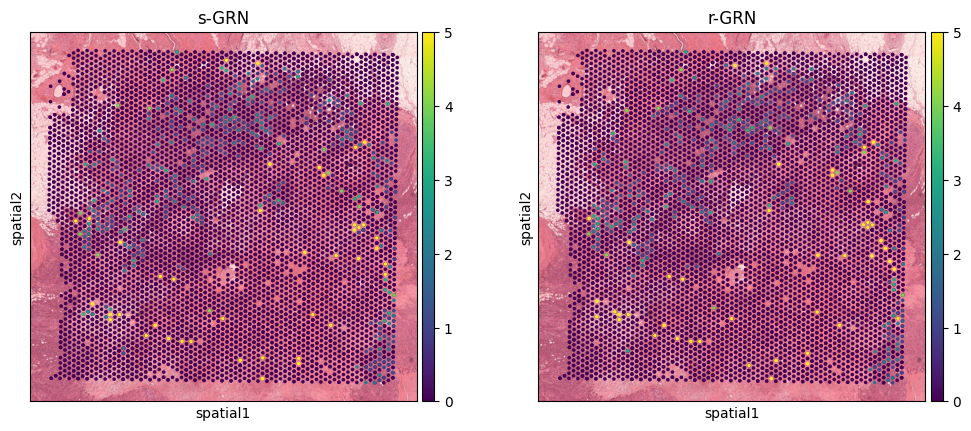

In [13]:
# Use the Midikine Pathway and do Anova Testing to see which Celltypes are significantly expressing or responding to it.

pathway = 'GRN'

if f's-{pathway}' in expanded_adata.obsm['commot-cellchat-sum-sender'].columns:
    expanded_adata.obs[f's-{pathway}'] = expanded_adata.obsm['commot-cellchat-sum-sender'][f's-{pathway}']
    expanded_adata.obs[f'r-{pathway}'] = expanded_adata.obsm['commot-cellchat-sum-receiver'][f'r-{pathway}']
else:
    expanded_adata.obs[f's-{pathway}'] = np.zeros(adata_0.n_obs)
    expanded_adata.obs[f'r-{pathway}'] = np.zeros(adata_0.n_obs)
sc.pl.spatial(expanded_adata, color=[f's-{pathway}',f'r-{pathway}'], wspace = 0, vmin = 0, vmax = 5)

In [14]:
# Get top 10 highest senders with their indices

print("Top 10 highest senders:")
top_senders = expanded_adata.obs[f's-{pathway}'].sort_values(ascending=False)[:10]
for idx, value in top_senders.items():
    print(f"Cell {idx}: {value:.4f}")

print("\nTop 10 highest receivers:")
top_receivers = expanded_adata.obs[f'r-{pathway}'].sort_values(ascending=False)[:10]
for idx, value in top_receivers.items():
    print(f"Cell {idx}: {value:.4f}")

Top 10 highest senders:
Cell GTCGTAGACTGACAAG-1_Fibroblasts: 19.0000
Cell GACTAGATTAGCTAAC-1_Fibroblasts: 12.9276
Cell AACTTCATCTTCTGGT-1_Cancer Cells: 12.0000
Cell CATACAATGAGTAGCT-1_Macrophages: 11.9969
Cell TGGACTGACGTACCAC-1_Fibroblasts: 11.0000
Cell CCTTAGTTATACCAGA-1_Cancer Cells: 11.0000
Cell ATTGCCTTGTCTAAGT-1_Fibroblasts: 11.0000
Cell TCCAGATCTTCGCTTA-1_Macrophages: 10.9915
Cell CTTAGTAAGCGTGGCA-1_Fibroblasts: 10.8903
Cell GGTGTCACCAGCGAAC-1_Fibroblasts: 10.0000

Top 10 highest receivers:
Cell AGGTACAGCTATGATA-1_CD4 T Cells: 19.0000
Cell TAACGAATGCTCCAAT-1_Fibroblasts: 15.0000
Cell GACTAGATTAGCTAAC-1_Fibroblasts: 13.0000
Cell GACAACTTGATTGTGA-1_Cancer Cells: 12.0000
Cell CATACAATGAGTAGCT-1_Macrophages: 12.0000
Cell GCAGATCGGTAATTAT-1_Cancer Cells: 11.2000
Cell CTTAGTAAGCGTGGCA-1_Fibroblasts: 11.0000
Cell TGGACTGACGTACCAC-1_Fibroblasts: 11.0000
Cell TCTGCGCTTGCAGATA-1_Fibroblasts: 11.0000
Cell TGGTGCCGCTGCAACA-1_Cancer Cells: 11.0000


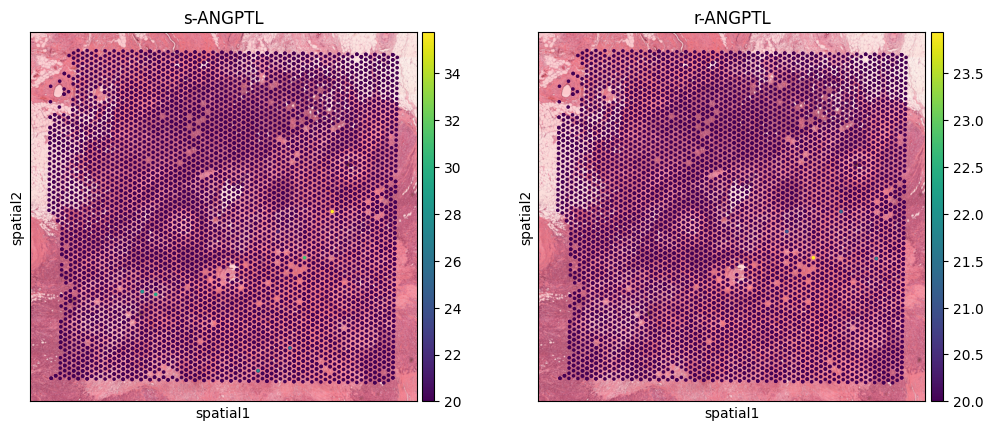

In [14]:
pathway = 'ANGPTL'

if f's-{pathway}' in expanded_adata.obsm['commot-cellchat-sum-sender'].columns:
    expanded_adata.obs[f's-{pathway}'] = expanded_adata.obsm['commot-cellchat-sum-sender'][f's-{pathway}']
    expanded_adata.obs[f'r-{pathway}'] = expanded_adata.obsm['commot-cellchat-sum-receiver'][f'r-{pathway}']
else:
    expanded_adata.obs[f's-{pathway}'] = np.zeros(adata_0.n_obs)
    expanded_adata.obs[f'r-{pathway}'] = np.zeros(adata_0.n_obs)
sc.pl.spatial(expanded_adata, color=[f's-{pathway}',f'r-{pathway}'], wspace = 0, vmin = 20,)

In [ ]:
#  Validate with OminPath